# Análisis Estadístico - Oposiciones GSI AGE (2018-2024)
### Basado íntegramente en las Memorias Oficiales de la CPS (INAP)

En este cuaderno se analizan las oposiciones del **Cuerpo de Gestión de Sistemas e Informática (GSI)** de la Administración del Estado:
1. **¿Cuánta gente echó la solicitud, cuánta se presentó y de los que se presentaron, cuántos lograron aprobar?**
2. **¿Cuántas plazas se quedan desiertas de todas las que se han convocado ese año?**
3. **Radiografía oficial de la convocatoria 2024 desglosada por cupo general y discapacidad.**
4. **Criba por ejercicios: ¿Cuántos superan el 1er ejercicio y cuántos el proceso completo?**
5. **Asignación en convocatorias acumuladas y destino histórico de los opositores.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.autolayout'] = True


## 1. Carga de Datos Oficiales y Preparación
Cargamos los datos del dataset maestro `gsi_datos_completos.csv` y calculamos las métricas directas.

In [2]:
df_completo = pd.read_csv('gsi_datos_completos.csv')

df_libre = df_completo[df_completo['tipo_acceso'] == 'Ingreso Libre'].sort_values('convocatoria').copy().reset_index(drop=True)
df_promo = df_completo[df_completo['tipo_acceso'] == 'Promoción Interna'].sort_values('convocatoria').copy().reset_index(drop=True)

for d in [df_libre, df_promo]:
    d['plazas_desiertas'] = d['plazas_totales'] - d['superan_proceso_total']
    d['pct_aprobados_de_presentados'] = (d['superan_proceso_total'] / d['presentados_1ej_total'] * 100).round(2)
    d['pct_plazas_desiertas'] = (d['plazas_desiertas'] / d['plazas_totales'] * 100).round(2)
    d['pct_presentados_de_solicitudes'] = (d['presentados_1ej_total'] / d['solicitudes_total'] * 100).round(2)

convocatorias = df_libre['convocatoria'].astype(str).tolist()
x = np.arange(len(convocatorias))


## 2. Ingreso Libre: Solicitudes, Presentados, Aprobados y Plazas Desiertas

> **Respuesta a la pregunta clave:** De las personas que echaron la solicitud y de las que fueron al examen, ¿cuántas lograron aprobar? ¿Y cuántas plazas quedaron sin cubrir?


In [3]:
tabla_libre = pd.DataFrame({
    'Convocatoria': df_libre['convocatoria'].astype(str),
    'Plazas Convocadas': df_libre['plazas_totales'],
    'Solicitudes (Instancias)': df_libre['solicitudes_total'],
    'Presentados (Al examen)': df_libre['presentados_1ej_total'],
    'Aprobados (Logran plaza)': df_libre['superan_proceso_total'],
    '% Aprobados / Presentados': df_libre['pct_aprobados_de_presentados'].map('{:.2f}%'.format),
    'Plazas Desiertas': df_libre['plazas_desiertas'],
    '% Plazas Desiertas': df_libre['pct_plazas_desiertas'].map('{:.2f}%'.format)
})

tot_lib_plz = df_libre['plazas_totales'].sum()
tot_lib_sol = df_libre['solicitudes_total'].sum()
tot_lib_pres = df_libre['presentados_1ej_total'].sum()
tot_lib_apr = df_libre['superan_proceso_total'].sum()
tot_lib_des = df_libre['plazas_desiertas'].sum()

fila_tot_libre = pd.DataFrame([{
    'Convocatoria': 'TOTAL HISTÓRICO',
    'Plazas Convocadas': tot_lib_plz,
    'Solicitudes (Instancias)': tot_lib_sol,
    'Presentados (Al examen)': tot_lib_pres,
    'Aprobados (Logran plaza)': tot_lib_apr,
    '% Aprobados / Presentados': f'{tot_lib_apr/tot_lib_pres*100:.2f}%',
    'Plazas Desiertas': tot_lib_des,
    '% Plazas Desiertas': f'{tot_lib_des/tot_lib_plz*100:.2f}%'
}])

tabla_libre_final = pd.concat([tabla_libre, fila_tot_libre], ignore_index=True)
tabla_libre_final


,Convocatoria,Plazas Convocadas,Solicitudes (Instancias),Presentados (Al examen),Aprobados (Logran plaza),% Aprobados / Presentados,Plazas Desiertas,% Plazas Desiertas
0,2018,218,2087,1027,144,14.02%,74,33.94%
1,2019,280,1574,719,143,19.89%,137,48.93%
2,2022,840,2437,1219,316,25.92%,524,62.38%
3,2024,995,2482,1033,410,39.69%,585,58.79%
4,TOTAL HISTÓRICO,2333,8580,3998,1013,25.34%,1320,56.58%


## 3. Resumen: ¿Cuántas plazas se quedan desiertas de todas las que se han convocado ese año? (Total GSI: Libre + Promo)

Sumando todas las modalidades ofertadas por el Estado en cada convocatoria (Ingreso Libre + Promoción Interna):


In [4]:
tot_plz_yr = df_libre['plazas_totales'] + df_promo['plazas_totales']
tot_sol_yr = df_libre['solicitudes_total'] + df_promo['solicitudes_total']
tot_pres_yr = df_libre['presentados_1ej_total'] + df_promo['presentados_1ej_total']
tot_apr_yr = df_libre['superan_proceso_total'] + df_promo['superan_proceso_total']
tot_des_yr = tot_plz_yr - tot_apr_yr

tabla_total_gsi = pd.DataFrame({
    'Convocatoria': convocatorias,
    'Plazas Convocadas': tot_plz_yr,
    'Solicitudes Totales': tot_sol_yr,
    'Presentados al Examen': tot_pres_yr,
    'Aprobados (Plazas Cubiertas)': tot_apr_yr,
    '% Aprobados / Presentados': (tot_apr_yr / tot_pres_yr * 100).round(2).map('{:.2f}%'.format),
    'Plazas Desiertas ese Año': tot_des_yr,
    '% Plazas Desiertas': (tot_des_yr / tot_plz_yr * 100).round(2).map('{:.2f}%'.format)
})

fila_tot_global = pd.DataFrame([{
    'Convocatoria': 'TOTAL HISTÓRICO',
    'Plazas Convocadas': tot_plz_yr.sum(),
    'Solicitudes Totales': tot_sol_yr.sum(),
    'Presentados al Examen': tot_pres_yr.sum(),
    'Aprobados (Plazas Cubiertas)': tot_apr_yr.sum(),
    '% Aprobados / Presentados': f'{tot_apr_yr.sum()/tot_pres_yr.sum()*100:.2f}%',
    'Plazas Desiertas ese Año': tot_des_yr.sum(),
    '% Plazas Desiertas': f'{tot_des_yr.sum()/tot_plz_yr.sum()*100:.2f}%'
}])

tabla_total_gsi_final = pd.concat([tabla_total_gsi, fila_tot_global], ignore_index=True)
tabla_total_gsi_final


,Convocatoria,Plazas Convocadas,Solicitudes Totales,Presentados al Examen,Aprobados (Plazas Cubiertas),% Aprobados / Presentados,Plazas Desiertas ese Año,% Plazas Desiertas
0,2018,358,2283,1203,175,14.55%,183,51.12%
1,2019,480,1883,942,254,26.96%,226,47.08%
2,2022,1440,2903,1488,459,30.85%,981,68.12%
3,2024,1795,2867,1219,572,46.92%,1223,68.13%
4,TOTAL HISTÓRICO,4073,9936,4852,1460,30.09%,2613,64.15%


## 4. Radiografía Oficial de la Convocatoria 2024 al Detalle por Cupos

Datos oficiales certificados en la Memoria CPS 2024 para Cupo General y Cupo Discapacidad (CRD):


In [5]:
tabla_2024 = pd.DataFrame([
    {
        'Modalidad / Cupo': 'Ingreso Libre - Cupo General',
        'Plazas Convocadas': 937, 'Solicitudes': 2389, 'Presentados 1º Ej': 1004,
        'Superan Proceso (Plaza)': 397, '% Superan / Presentados': '39.54%',
        'Plazas Desiertas': 540, '% Plazas Desiertas': '57.63%'
    },
    {
        'Modalidad / Cupo': 'Ingreso Libre - Discapacidad (CRD)',
        'Plazas Convocadas': 58, 'Solicitudes': 93, 'Presentados 1º Ej': 29,
        'Superan Proceso (Plaza)': 13, '% Superan / Presentados': '44.83%',
        'Plazas Desiertas': 45, '% Plazas Desiertas': '77.59%'
    },
    {
        'Modalidad / Cupo': 'TOTAL INGRESO LIBRE 2024',
        'Plazas Convocadas': 995, 'Solicitudes': 2482, 'Presentados 1º Ej': 1033,
        'Superan Proceso (Plaza)': 410, '% Superan / Presentados': '39.69%',
        'Plazas Desiertas': 585, '% Plazas Desiertas': '58.79%'
    },
    {
        'Modalidad / Cupo': 'Promoción Interna - Cupo General',
        'Plazas Convocadas': 754, 'Solicitudes': 366, 'Presentados 1º Ej': 178,
        'Superan Proceso (Plaza)': 155, '% Superan / Presentados': '87.08%',
        'Plazas Desiertas': 599, '% Plazas Desiertas': '79.44%'
    },
    {
        'Modalidad / Cupo': 'Promoción Interna - Discapacidad (CRD)',
        'Plazas Convocadas': 46, 'Solicitudes': 19, 'Presentados 1º Ej': 8,
        'Superan Proceso (Plaza)': 7, '% Superan / Presentados': '87.50%',
        'Plazas Desiertas': 39, '% Plazas Desiertas': '84.78%'
    },
    {
        'Modalidad / Cupo': 'TOTAL PROMOCIÓN INTERNA 2024',
        'Plazas Convocadas': 800, 'Solicitudes': 385, 'Presentados 1º Ej': 186,
        'Superan Proceso (Plaza)': 162, '% Superan / Presentados': '87.10%',
        'Plazas Desiertas': 638, '% Plazas Desiertas': '79.75%'
    },
    {
        'Modalidad / Cupo': 'TOTAL CONJUNTO GSI 2024',
        'Plazas Convocadas': 1795, 'Solicitudes': 2867, 'Presentados 1º Ej': 1219,
        'Superan Proceso (Plaza)': 572, '% Superan / Presentados': '46.92%',
        'Plazas Desiertas': 1223, '% Plazas Desiertas': '68.13%'
    }
])
tabla_2024


,Modalidad / Cupo,Plazas Convocadas,Solicitudes,Presentados 1º Ej,Superan Proceso (Plaza),% Superan / Presentados,Plazas Desiertas,% Plazas Desiertas
0,Ingreso Libre - Cupo General,937,2389,1004,397,39.54%,540,57.63%
1,Ingreso Libre - Discapacidad (CRD),58,93,29,13,44.83%,45,77.59%
2,TOTAL INGRESO LIBRE 2024,995,2482,1033,410,39.69%,585,58.79%
3,Promoción Interna - Cupo General,754,366,178,155,87.08%,599,79.44%
4,Promoción Interna - Discapacidad (CRD),46,19,8,7,87.50%,39,84.78%
5,TOTAL PROMOCIÓN INTERNA 2024,800,385,186,162,87.10%,638,79.75%
6,TOTAL CONJUNTO GSI 2024,1795,2867,1219,572,46.92%,1223,68.13%


## 5. Progresión por Ejercicios: ¿Cuántos superan el 1er Ejercicio y cuántos el Proceso Completo?

Analizamos la progresión del filtro:
- En **2018 y 2019**, los exámenes fueron en días separados (1º Ejercicio Test y 2º Ejercicio Práctico).
- En **2022 y 2024**, se realizó en una única jornada (Examen Único conjunto).


In [6]:
tabla_criba = pd.DataFrame([
    {
        'Convocatoria': '2018',
        'Tipo Examen': 'Dos exámenes separados',
        'Presentados 1º Ej': 1027,
        'Superan 1º Ej (Test)': 500,
        '% Superan 1º Ej': '48.69%',
        'Presentados 2º Ej': 350,
        'Superan Proceso (Plaza)': 144,
        '% Superan Proceso / Presentados 1º': '14.02%'
    },
    {
        'Convocatoria': '2019',
        'Tipo Examen': 'Dos exámenes separados',
        'Presentados 1º Ej': 719,
        'Superan 1º Ej (Test)': 350,
        '% Superan 1º Ej': '48.68%',
        'Presentados 2º Ej': 261,
        'Superan Proceso (Plaza)': 143,
        '% Superan Proceso / Presentados 1º': '19.89%'
    },
    {
        'Convocatoria': '2022',
        'Tipo Examen': 'Examen Único (Test + Caso)',
        'Presentados 1º Ej': 1219,
        'Superan 1º Ej (Test)': 'Sesión conjunta',
        '% Superan 1º Ej': '—',
        'Presentados 2º Ej': 'Misma sesión',
        'Superan Proceso (Plaza)': 316,
        '% Superan Proceso / Presentados 1º': '25.92%'
    },
    {
        'Convocatoria': '2024',
        'Tipo Examen': 'Examen Único (Test + Caso)',
        'Presentados 1º Ej': 1033,
        'Superan 1º Ej (Test)': 'Sesión conjunta',
        '% Superan 1º Ej': '—',
        'Presentados 2º Ej': 'Misma sesión',
        'Superan Proceso (Plaza)': 410,
        '% Superan Proceso / Presentados 1º': '39.69%'
    }
])
tabla_criba


,Convocatoria,Tipo Examen,Presentados 1º Ej,Superan 1º Ej (Test),% Superan 1º Ej,Presentados 2º Ej,Superan Proceso (Plaza),% Superan Proceso / Presentados 1º
0,2018,Dos exámenes separados,1027,500,48.69%,350,144,14.02%
1,2019,Dos exámenes separados,719,350,48.68%,261,143,19.89%
2,2022,Examen Único (Test + Caso),1219,Sesión conjunta,—,Misma sesión,316,25.92%
3,2024,Examen Único (Test + Caso),1033,Sesión conjunta,—,Misma sesión,410,39.69%


## 6. Visualizaciones Clave

### Gráfico 1: Solicitudes vs Presentados vs Aprobados (Ingreso Libre)


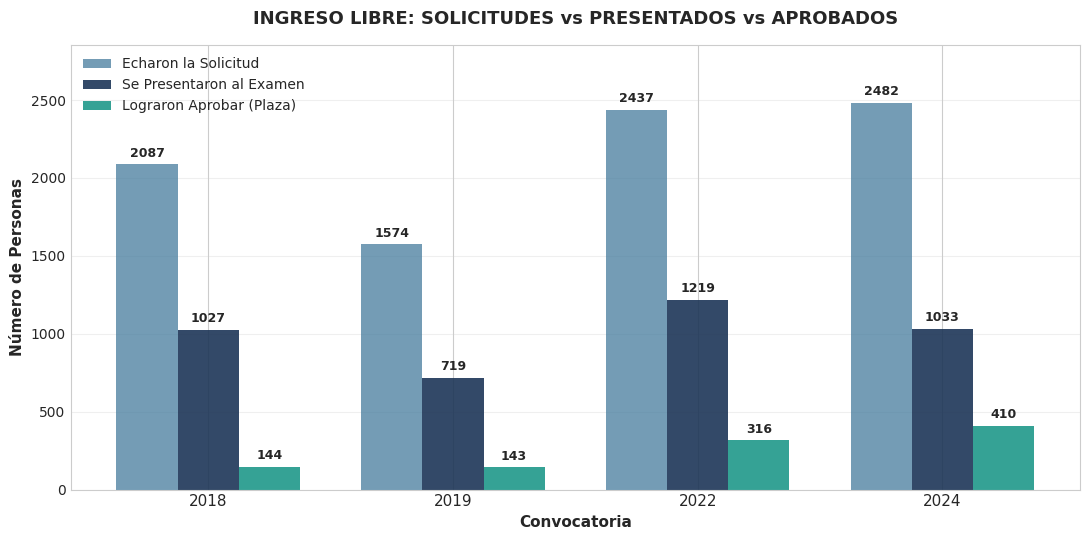

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
width_grp = 0.25

b_sol = ax.bar(x - width_grp, df_libre['solicitudes_total'], width_grp, label='Echaron la Solicitud', color='#457B9D', alpha=0.75)
b_pres = ax.bar(x, df_libre['presentados_1ej_total'], width_grp, label='Se Presentaron al Examen', color='#1D3557', alpha=0.9)
b_apr = ax.bar(x + width_grp, df_libre['superan_proceso_total'], width_grp, label='Lograron Aprobar (Plaza)', color='#2A9D8F', alpha=0.95)

ax.set_title('INGRESO LIBRE: SOLICITUDES vs PRESENTADOS vs APROBADOS', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Personas', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(convocatorias, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(df_libre['solicitudes_total']) * 1.15)

for bars in [b_sol, b_pres, b_apr]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 30, f'{int(h)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
tabla_aprobados_presentados = pd.DataFrame({
    'Convocatoria': df_libre['convocatoria'].astype(str),
    'Presentados Ingreso Libre': df_libre['presentados_1ej_total'],
    'Aprobados Ingreso Libre': df_libre['superan_proceso_total'],
    '% Aprobados / Presentados (Ingreso Libre)': (
        df_libre['superan_proceso_total'] / df_libre['presentados_1ej_total'] * 100
    ).round(2).map('{:.2f}%'.format),
    'Presentados Promoción Interna': df_promo['presentados_1ej_total'],
    'Aprobados Promoción Interna': df_promo['superan_proceso_total'],
    '% Aprobados / Presentados (Promoción Interna)': (
        df_promo['superan_proceso_total'] / df_promo['presentados_1ej_total'] * 100
    ).round(2).map('{:.2f}%'.format)
})

fila_total_aprobados_presentados = pd.DataFrame([{
    'Convocatoria': 'TOTAL HISTÓRICO',
    'Presentados Ingreso Libre': df_libre['presentados_1ej_total'].sum(),
    'Aprobados Ingreso Libre': df_libre['superan_proceso_total'].sum(),
    '% Aprobados / Presentados (Ingreso Libre)': (
        df_libre['superan_proceso_total'].sum()
        / df_libre['presentados_1ej_total'].sum() * 100
    ).round(2).astype(str) + '%',
    'Presentados Promoción Interna': df_promo['presentados_1ej_total'].sum(),
    'Aprobados Promoción Interna': df_promo['superan_proceso_total'].sum(),
    '% Aprobados / Presentados (Promoción Interna)': (
        df_promo['superan_proceso_total'].sum()
        / df_promo['presentados_1ej_total'].sum() * 100
    ).round(2).astype(str) + '%'
}])

tabla_aprobados_presentados_final = pd.concat(
    [tabla_aprobados_presentados, fila_total_aprobados_presentados],
    ignore_index=True
)
tabla_aprobados_presentados_final

### Gráfico 2: De los que se presentaron, ¿qué porcentaje logró aprobar?


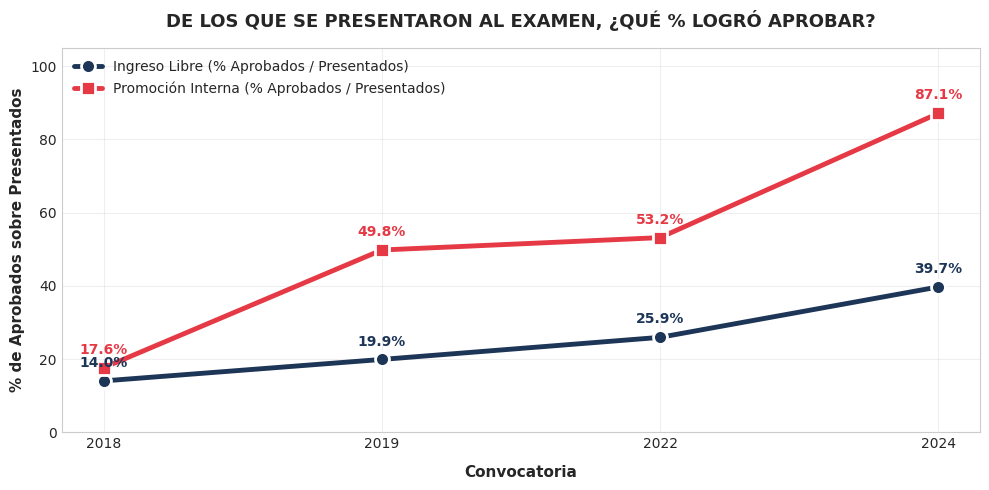

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(convocatorias, df_libre['pct_aprobados_de_presentados'], 'o-', linewidth=3.5, markersize=10, 
        label='Ingreso Libre (% Aprobados / Presentados)', color='#1D3557', markeredgecolor='white', markeredgewidth=2)
ax.plot(convocatorias, df_promo['pct_aprobados_de_presentados'], 's-', linewidth=3.5, markersize=10, 
        label='Promoción Interna (% Aprobados / Presentados)', color='#E63946', markeredgecolor='white', markeredgewidth=2)

ax.set_xlabel('Convocatoria', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('% de Aprobados sobre Presentados', fontsize=11, fontweight='bold')
ax.set_title('DE LOS QUE SE PRESENTARON AL EXAMEN, ¿QUÉ % LOGRÓ APROBAR?', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper left')

for i, (v_lib, v_pro) in enumerate(zip(df_libre['pct_aprobados_de_presentados'], df_promo['pct_aprobados_de_presentados'])):
    ax.annotate(f'{v_lib:.1f}%', (i, v_lib), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold', color='#1D3557')
    ax.annotate(f'{v_pro:.1f}%', (i, v_pro), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold', color='#E63946')

plt.tight_layout()
plt.show()


### Gráfico 3: ¿Cuántas plazas quedan desiertas de todas las convocadas ese año?
Comparativa de Plazas Cubiertas vs Plazas Desiertas para Ingreso Libre y Total GSI.


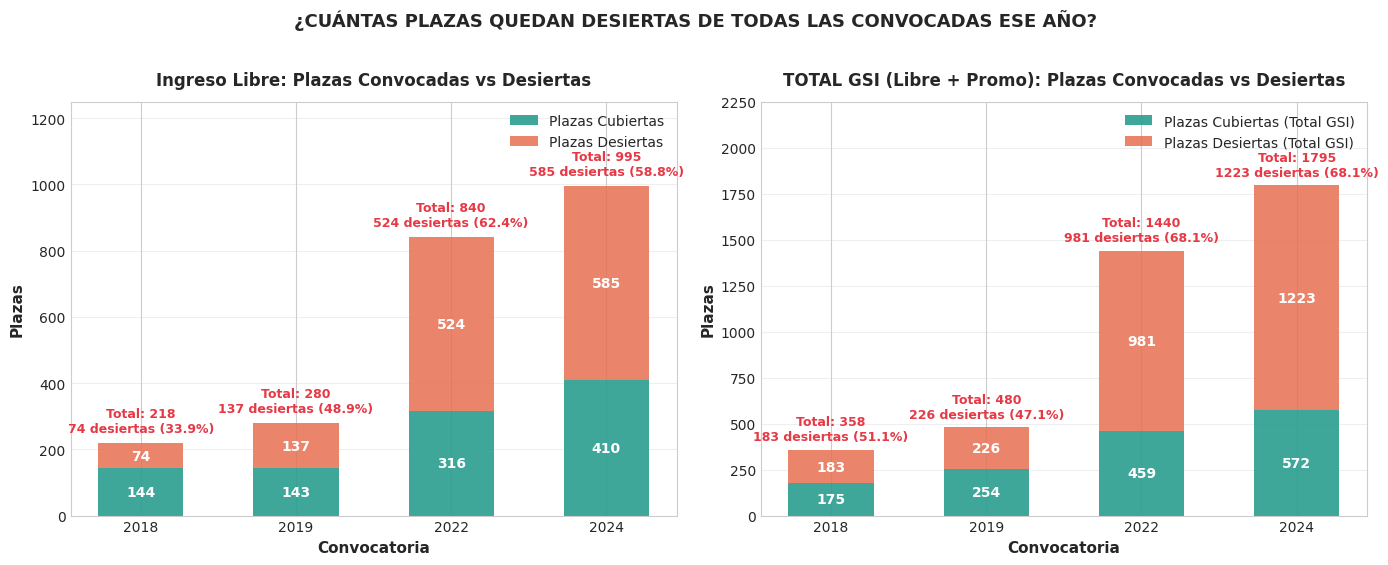

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Libre
ax1.bar(convocatorias, df_libre['superan_proceso_total'], width=0.55, label='Plazas Cubiertas', color='#2A9D8F', alpha=0.9)
ax1.bar(convocatorias, df_libre['plazas_desiertas'], width=0.55, bottom=df_libre['superan_proceso_total'], label='Plazas Desiertas', color='#E76F51', alpha=0.85)
ax1.set_title('Ingreso Libre: Plazas Convocadas vs Desiertas', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax1.set_ylabel('Plazas', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1250)

for i in range(len(convocatorias)):
    tot = df_libre['plazas_totales'].iloc[i]
    des = df_libre['plazas_desiertas'].iloc[i]
    cub = df_libre['superan_proceso_total'].iloc[i]
    pct_d = df_libre['pct_plazas_desiertas'].iloc[i]
    ax1.text(i, tot + 25, f'Total: {tot}\n{des} desiertas ({pct_d:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#E63946')
    ax1.text(i, cub/2, f'{cub}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax1.text(i, cub + des/2, f'{des}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Total GSI (Libre + Promo)
ax2.bar(convocatorias, tot_apr_yr, width=0.55, label='Plazas Cubiertas (Total GSI)', color='#2A9D8F', alpha=0.9)
ax2.bar(convocatorias, tot_des_yr, width=0.55, bottom=tot_apr_yr, label='Plazas Desiertas (Total GSI)', color='#E76F51', alpha=0.85)
ax2.set_title('TOTAL GSI (Libre + Promo): Plazas Convocadas vs Desiertas', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax2.set_ylabel('Plazas', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 2250)

for i in range(len(convocatorias)):
    tot_g = tot_plz_yr.iloc[i]
    des_g = tot_des_yr.iloc[i]
    cub_g = tot_apr_yr.iloc[i]
    pct_dg = des_g / tot_g * 100
    ax2.text(i, tot_g + 35, f'Total: {tot_g}\n{des_g} desiertas ({pct_dg:.1f}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#E63946')
    ax2.text(i, cub_g/2, f'{cub_g}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax2.text(i, cub_g + des_g/2, f'{des_g}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.suptitle('¿CUÁNTAS PLAZAS QUEDAN DESIERTAS DE TODAS LAS CONVOCADAS ESE AÑO?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Gráfico 4: Destino Global de los Aspirantes de Ingreso Libre (2018-2024)
Distribución acumulada de las 8.580 personas que echaron la solicitud.


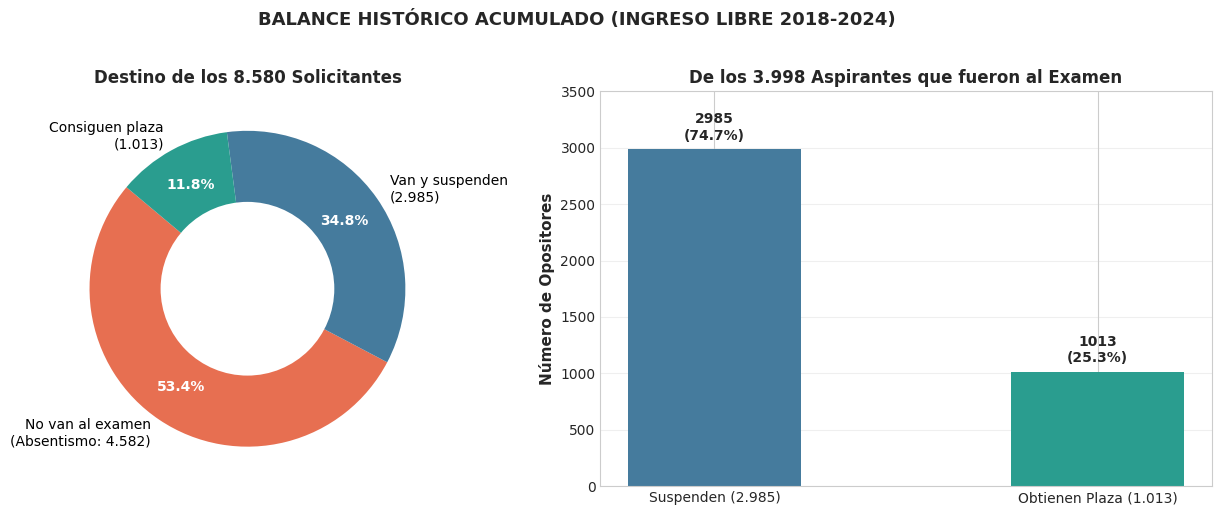

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Donut chart
labels = ['No van al examen\n(Absentismo: 4.582)', 'Van y suspenden\n(2.985)', 'Consiguen plaza\n(1.013)']
sizes = [4582, 2985, 1013]
colors = ['#E76F51', '#457B9D', '#2A9D8F']

wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
                                   colors=colors, pctdistance=0.75,
                                   textprops=dict(color='black', fontsize=10))
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')

centre_circle = plt.Circle((0,0), 0.55, fc='white')
ax1.add_artist(centre_circle)
ax1.set_title('Destino de los 8.580 Solicitantes', fontsize=12, fontweight='bold')

# Bar chart: De los 3.998 que fueron al examen
labels_pres = ['Suspenden (2.985)', 'Obtienen Plaza (1.013)']
sizes_pres = [2985, 1013]
pcts_pres = [2985/3998*100, 1013/3998*100]
bars = ax2.bar(labels_pres, sizes_pres, color=['#457B9D', '#2A9D8F'], width=0.45)
ax2.set_title('De los 3.998 Aspirantes que fueron al Examen', fontsize=12, fontweight='bold')
ax2.set_ylabel('Número de Opositores', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 3500)
ax2.grid(True, alpha=0.3, axis='y')

for bar, pct in zip(bars, pcts_pres):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 60, f'{int(h)}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('BALANCE HISTÓRICO ACUMULADO (INGRESO LIBRE 2018-2024)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Conclusiones y Resumen para el Opositor

1. **De los que se presentan, ¿cuántos logran aprobar?:**
   - En **2024**, de 1.033 presentados, lograron plaza **410 aspirantes (39.69%)**.
   - En el **histórico acumulado (2018-2024)**, de 3.998 personas que acudieron a la prueba, lograron plaza **1.013 aspirantes (25.34%)**.

2. **¿Cuántas plazas quedan desiertas de todas las que se han convocado ese año?:**
   - En la convocatoria de **2024**, de 1.795 plazas convocadas en total (Libre + Promo), quedaron desiertas **1.223 plazas (el 68.13%)**.
   - En el histórico conjunto de las 4 convocatorias (2018-2024), de 4.073 plazas ofertadas, **2.613 han quedado totalmente vacías (el 64.15%)**.

3. **El verdadero listón es el corte mínimo, no los competidores:**
   - En 2024 hubo prácticamente un opositor por plaza ofertada (ratio de 1.04 presentados por plaza en Libre).
   - Quedaron 585 plazas desiertas en Libre porque 623 opositores no lograron alcanzar el 50% de la nota de corte mínima fijada en las bases. Quien supera el corte obtiene plaza fija.
